# Phase 12 (Bonus) — Rule-level Evolution: thêm / bớt luật với nhãn phản hồi trễ

Cơ chế Phase 7 chỉ tịnh tiến MF, không đổi luật. Phase này thử bước "khó nhất" trong thứ tự độ khó của kế hoạch: **thêm/bớt luật**.

**Khác biệt về thiết lập, cần nói rõ:** thêm hoặc bớt luật cần biết một cảnh báo là đúng hay sai, tức cần **nhãn**. Ta giả định nhãn của mẫu $x_t$ về tới hệ thống sau `label_delay` bước, ví dụ sau kiểm tra hoặc sửa chữa. Nhãn chỉ được dùng để sửa rule base *từ thời điểm nó về trở đi*; bản thân $x_t$ đã được chấm điểm bằng rule base cũ (prequential). Đây là thiết lập **có giám sát trễ**, khác với MF adaptation không giám sát của Phase 7.

- **ADD:** một ca lỗi bị bỏ sót đề xuất các luật ứng viên `IF <2–3 term không phải MEDIUM của mẫu đó> THEN HIGH`. Ứng viên chỉ được thêm nếu trên các mẫu *đã có nhãn trong quá khứ*, nó kích hoạt mạnh (α ≥ 0.5) ít nhất 3 lần, trúng ít nhất 2 ca lỗi, và precision ≥ ngưỡng (*quality gate*).
- **REMOVE:** một luật MEDIUM/HIGH bị bỏ khi, trong ít nhất 20 cảnh báo mà nó kích hoạt mạnh, precision < ngưỡng. Luật LOW không bao giờ bị bỏ.

Siêu tham số được **chọn trên Validation** (UDI 6001–8000, cùng giao thức tiêm drift), rồi mới áp dụng lên Test.

In [1]:
import sys, itertools
from pathlib import Path
ROOT = Path.cwd().parent; sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src.data import load_dataset, make_scenarios, make_validation_scenarios
from src.rule_evolution import RuleEvolvingRunner
from src.evolving import PrequentialRunner
from src.evaluation import evaluate
from src.fuzzy import format_rule, RULES
df = load_dataset(); test_sc = make_scenarios(df); val_sc = make_validation_scenarios(df)
pd.set_option("display.max_colwidth", 140); pd.set_option("display.width", 220)
for k, s in val_sc.items(): print("Validation", k, "failures =", int(s["Machine failure"].sum()))

def run(stream, mf=True, **kw):
    r = RuleEvolvingRunner(evolve=mf, **kw) if kw.get("add_rules", True) or kw.get("remove_rules", True) else PrequentialRunner(evolve=mf)
    log = r.run(stream); m = evaluate(log.label, log.score)
    return r, log, m

Validation Control failures = 45
Validation Sudden Drift failures = 45
Validation Gradual Drift failures = 45


## 12.1 — Vì sao cần quality gate: thêm luật từ một mẫu duy nhất (Test, chỉ để minh họa)

In [2]:
rows = []
for scen, s in test_sc.items():
    r, log, m = run(s, mf=True, quality_gate=False, remove_rules=False, label_delay=0)
    rows.append({"Scenario": scen, "rules added": sum(x["action"] == "add" for x in r.rule_log), "rules at end": r.fis.n_rules,
                 "TP": m["TP"], "FP": m["FP"], "FN": m["FN"], "F1": round(m["F1"], 4), "FPR": round(m["FPR"], 4)})
naive_df = pd.DataFrame(rows)
print("Reference MF-only (E2/E4/E5b): F1 0.3023 / 0.2727 / 0.2456, FPR 0.0173 / 0.0286 / 0.0311")
naive_df

Reference MF-only (E2/E4/E5b): F1 0.3023 / 0.2727 / 0.2456, FPR 0.0173 / 0.0286 / 0.0311


,Scenario,rules added,rules at end,TP,FP,FN,F1,FPR
0,Control,14,26,17,122,22,0.1910,0.0622
1,Sudden Drift,14,26,20,182,19,0.1660,0.0928
2,Gradual Drift,12,24,22,213,17,0.1606,0.1086


## 12.2 — Chọn siêu tham số trên Validation

Lưới: `remove_min_precision` ∈ {tắt, 0.05, 0.10, 0.15, 0.20} × `add` ∈ {tắt, gate 0.2, gate 0.3}; luôn bật MF adaptation; label_delay = 0. Tiêu chí: F1 trung bình trên 3 luồng Validation.

In [3]:
grid = []
for rem, add in itertools.product([None, 0.05, 0.10, 0.15, 0.20], [None, 0.2, 0.3]):
    f1s, fprs, nr = [], [], []
    for scen, s in val_sc.items():
        kw = dict(label_delay=0, remove_rules=rem is not None, min_precision=rem or 0.05,
                  add_rules=add is not None, min_add_precision=add or 0.3)
        if rem is None and add is None:
            r = PrequentialRunner(evolve=True); log = r.run(s); m = evaluate(log.label, log.score); n = 12
        else:
            r, log, m = run(s, mf=True, **kw); n = r.fis.n_rules
        f1s.append(m["F1"]); fprs.append(m["FPR"]); nr.append(n)
    grid.append({"remove_min_precision": rem or "off", "add_gate_precision": add or "off",
                 "F1 Control": f1s[0], "F1 Sudden": f1s[1], "F1 Gradual": f1s[2], "mean F1": np.mean(f1s),
                 "mean FPR": np.mean(fprs), "rules at end (C/S/G)": nr})
grid_df = pd.DataFrame(grid).sort_values("mean F1", ascending=False)
best = grid_df.iloc[0]
print("Selected on Validation:", dict(best[["remove_min_precision", "add_gate_precision", "mean F1"]]))
grid_df.round(4)

Selected on Validation: {'remove_min_precision': 'off', 'add_gate_precision': 0.3, 'mean F1': np.float64(0.2083125757609373)}


,remove_min_precision,add_gate_precision,F1 Control,F1 Sudden,F1 Gradual,mean F1,mean FPR,rules at end (C/S/G)
2,off,0.3,0.2044,0.2128,0.2078,0.2083,0.0430,"[14, 14, 14]"
5,0.05,0.3,0.2044,0.2128,0.2078,0.2083,0.0430,"[14, 14, 14]"
8,0.1,0.3,0.2044,0.2128,0.2078,0.2083,0.0430,"[14, 14, 14]"
7,0.1,0.2,0.2024,0.1988,0.2081,0.2031,0.0554,"[14, 14, 14]"
6,0.1,off,0.2105,0.1940,0.1983,0.2010,0.0365,"[12, 12, 10]"
3,0.05,off,0.2105,0.1940,0.1781,0.1942,0.0406,"[12, 12, 12]"
0,off,off,0.2105,0.1940,0.1781,0.1942,0.0406,"[12, 12, 12]"
11,0.15,0.3,0.2600,0.1389,0.1488,0.1825,0.0338,"[12, 8, 8]"
14,0.2,0.3,0.2062,0.2174,0.1053,0.1763,0.0303,"[8, 8, 8]"
9,0.15,off,0.2680,0.1250,0.1190,0.1707,0.0176,"[10, 7, 7]"


## 12.3 — Áp dụng cấu hình đã chọn lên Test (label_delay 0 và 200)

In [4]:
rem = None if best.remove_min_precision == "off" else float(best.remove_min_precision)
add = None if best.add_gate_precision == "off" else float(best.add_gate_precision)
ref = pd.read_csv(ROOT / "results" / "09_experiment_matrix.csv")
rows, keep = [], {}
for scen, s in test_sc.items():
    for mf in [False, True]:
        base = ref[(ref.Scenario == scen) & (ref.Model == ("Evolving" if mf else "Static"))].iloc[0]
        rows.append({"Scenario": scen, "System": ("MF" if mf else "Static") + " (reference)", "delay": "—",
                     "TP": base.TP, "FP": base.FP, "FN": base.FN, "F1": round(base.F1, 4), "FPR": round(base.FPR, 4), "rules": 12, "changes": ""})
        if rem is None and add is None:
            continue
        for delay in [0, 200]:
            r, log, m = run(s, mf=mf, label_delay=delay, remove_rules=rem is not None, min_precision=rem or 0.05,
                            add_rules=add is not None, min_add_precision=add or 0.3)
            keep[(scen, mf, delay)] = (r, log)
            rows.append({"Scenario": scen, "System": ("MF + Rule" if mf else "Rule only"), "delay": delay,
                         "TP": m["TP"], "FP": m["FP"], "FN": m["FN"], "F1": round(m["F1"], 4), "FPR": round(m["FPR"], 4),
                         "rules": r.fis.n_rules, "changes": "; ".join(f"{x['action']} {x['rule']}@t={x['t']}" for x in r.rule_log)})
test_df = pd.DataFrame(rows); test_df

,Scenario,System,delay,TP,FP,FN,F1,FPR,rules,changes
0,Control,Static (reference),—,13,34,26,0.3023,0.0173,12,
1,Control,Rule only,0,13,34,26,0.3023,0.0173,12,
2,Control,Rule only,200,13,34,26,0.3023,0.0173,12,
3,Control,MF (reference),—,13,34,26,0.3023,0.0173,12,
4,Control,MF + Rule,0,13,34,26,0.3023,0.0173,12,
5,Control,MF + Rule,200,13,34,26,0.3023,0.0173,12,
6,Sudden Drift,Static (reference),—,18,114,21,0.2105,0.0581,12,
7,Sudden Drift,Rule only,0,18,114,21,0.2105,0.0581,12,
8,Sudden Drift,Rule only,200,18,114,21,0.2105,0.0581,12,
9,Sudden Drift,MF (reference),—,15,56,24,0.2727,0.0286,12,


## 12.4 — Luật được thêm/bớt với cấu hình đã chọn (trên Validation, nơi cơ chế thực sự kích hoạt)

In [5]:
val_keep = {}
for scen, s in val_sc.items():
    r, log, m = run(s, mf=True, label_delay=0, remove_rules=rem is not None, min_precision=rem or 0.05,
                    add_rules=add is not None, min_add_precision=add or 0.3)
    val_keep[scen] = (r, log)
    print(f"\n[{scen}] F1={m['F1']:.4f} FPR={m['FPR']:.4f} rules {12}→{r.fis.n_rules}")
    for x in r.rule_log:
        extra = f"  (history: fired {x['hist_fires']}x, {x['hist_tp']} failures)" if x["action"] == "add" else f"  (alarms={x['alarms']}, true={x['tp']})"
        print(f"  t={x['t']:4d} [{x['action'].upper()}] {x['rule']}: {format_rule(x['antecedents'], x['consequent'])}{extra}")
for (scen, mf, delay), (r, log) in keep.items():
    if r.rule_log:
        print("Test changes:", scen, mf, delay, r.rule_log)
print("\nTest: number of rule changes across all runs =", sum(len(r.rule_log) for r, _ in keep.values()))


[Control] F1=0.2044 FPR=0.0399 rules 12→14
  t= 159 [ADD] N1: IF process_temp is HIGH AND torque is HIGH AND tool_wear is HIGH THEN anomaly is HIGH  (history: fired 5x, 3 failures)
  t= 678 [ADD] N2: IF air_temp is HIGH AND process_temp is HIGH AND torque is HIGH THEN anomaly is HIGH  (history: fired 10x, 3 failures)



[Sudden Drift] F1=0.2128 FPR=0.0414 rules 12→14
  t= 159 [ADD] N1: IF process_temp is HIGH AND torque is HIGH AND tool_wear is HIGH THEN anomaly is HIGH  (history: fired 5x, 3 failures)
  t= 678 [ADD] N2: IF air_temp is HIGH AND process_temp is HIGH AND torque is HIGH THEN anomaly is HIGH  (history: fired 10x, 3 failures)



[Gradual Drift] F1=0.2078 FPR=0.0476 rules 12→14
  t= 159 [ADD] N1: IF process_temp is HIGH AND torque is HIGH AND tool_wear is HIGH THEN anomaly is HIGH  (history: fired 5x, 3 failures)
  t= 678 [ADD] N2: IF air_temp is HIGH AND process_temp is HIGH AND torque is HIGH THEN anomaly is HIGH  (history: fired 10x, 3 failures)

Test: number of rule changes across all runs = 0


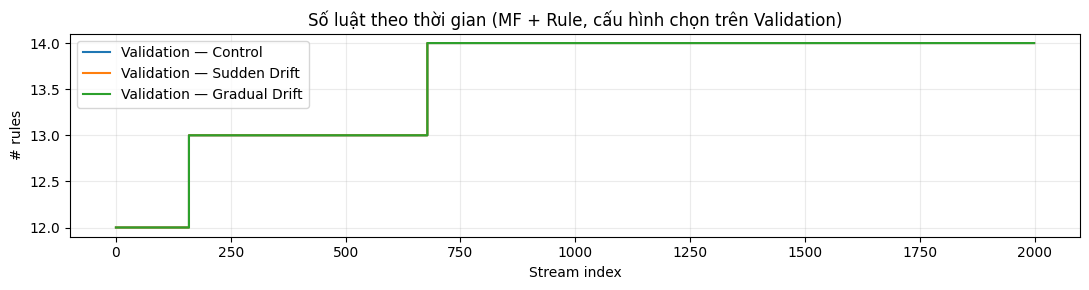

In [6]:
fig, ax = plt.subplots(figsize=(11, 3))
for scen, (r, log) in val_keep.items():
    ax.step(log.t, log.n_rules, where="post", label=f"Validation — {scen}")
ax.set_xlabel("Stream index"); ax.set_ylabel("# rules"); ax.set_title("Số luật theo thời gian (MF + Rule, cấu hình chọn trên Validation)"); ax.legend(); ax.grid(alpha=.25)
plt.tight_layout(); plt.savefig(ROOT / "figures" / "12_rule_count_timeline_validation.png", dpi=130); plt.show()

In [7]:
naive_df.to_csv(ROOT / "results" / "12_naive_rule_add.csv", index=False)
grid_df.to_csv(ROOT / "results" / "12_validation_grid.csv", index=False)
test_df.to_csv(ROOT / "results" / "12_test_rule_evolution.csv", index=False)
print("Phase 12: COMPLETE")

Phase 12: COMPLETE
